# Decision Tree Model: Predicting Disruptions in Shipments

Decision trees might be a good call since there's a lot of non-linear relationships in the columns that can be tackled individually. To this end, I've created a few models that use decision trees and random forests.

In [2]:
# Number and dataframe manipulation libraries
import numpy as np
import pandas as pd
import scipy.stats as sst
import graphviz
# EDA tools
import matplotlib.pyplot as plt
import missingno as poke
import seaborn as sns
from datetime import datetime as dt

# Pipeline components
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
# Decision tree and random forest
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.ensemble import RandomForestClassifier
# Split and validation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
# Metrics 
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    classification_report
)

# Other tools

# Copy module: Allows deep copy of any python object 
# (Used to deep copy a DecisionTreeClassifier without affecting)
import copy

random_seed = 809 #Please check the Pokedex for clarification on this random seed.

In [3]:
# Read in data
supply = pd.read_csv('supply_chain.csv')

## EDA
Let's see what this dataset has to offer, and what could be conducive to or problematic for this model.

In [4]:
# Get some basics about the data
supply.info()
# Looks like this dataset doesn't have any missing values. Fantastic!

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Shipment_ID                5000 non-null   str    
 1   Date                       5000 non-null   str    
 2   Origin_Port                5000 non-null   str    
 3   Destination_Port           5000 non-null   str    
 4   Transport_Mode             5000 non-null   str    
 5   Product_Category           5000 non-null   str    
 6   Distance_km                5000 non-null   float64
 7   Weight_MT                  5000 non-null   float64
 8   Fuel_Price_Index           5000 non-null   float64
 9   Geopolitical_Risk_Score    5000 non-null   float64
 10  Weather_Condition          5000 non-null   str    
 11  Carrier_Reliability_Score  5000 non-null   float64
 12  Lead_Time_Days             5000 non-null   float64
 13  Disruption_Occurred        5000 non-null   int64  
dtypes: 

In [5]:
# Numeric column details
supply.describe()

,Distance_km,Weight_MT,Fuel_Price_Index,Geopolitical_Risk_Score,Carrier_Reliability_Score,Lead_Time_Days,Disruption_Occurred
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,7704.063888,246.252052,2.854552,5.076900,0.754387,19.355386,0.612600
std,4199.687885,142.522591,0.959533,2.877832,0.144363,31.405143,0.487205
min,500.170000,1.030000,1.200000,0.000000,0.500000,0.500000,0.000000
25%,4036.010000,124.330000,2.020000,2.600000,0.629000,2.110000,0.000000
50%,7750.125000,243.500000,2.840000,5.100000,0.757000,8.245000,1.000000
75%,11347.462500,366.955000,3.710000,7.500000,0.879000,21.207500,1.000000
max,14995.910000,499.750000,4.500000,10.000000,1.000000,236.390000,1.000000


In [6]:
# Let's see how many unique values there are...
supply.nunique()

Shipment_ID                  5000
Date                          731
Origin_Port                     8
Destination_Port                9
Transport_Mode                  4
Product_Category                5
Distance_km                  4998
Weight_MT                    4785
Fuel_Price_Index              331
Geopolitical_Risk_Score       101
Weather_Condition               5
Carrier_Reliability_Score     501
Lead_Time_Days               2601
Disruption_Occurred             2
dtype: int64

In [7]:
# Drop shipment ID because it's an identifier column
supply = supply.drop(columns=['Shipment_ID'])

The categorical columns like departure and arrival location could be problematic. There's a lot of different factors for each. Let's see if we can condense anything.

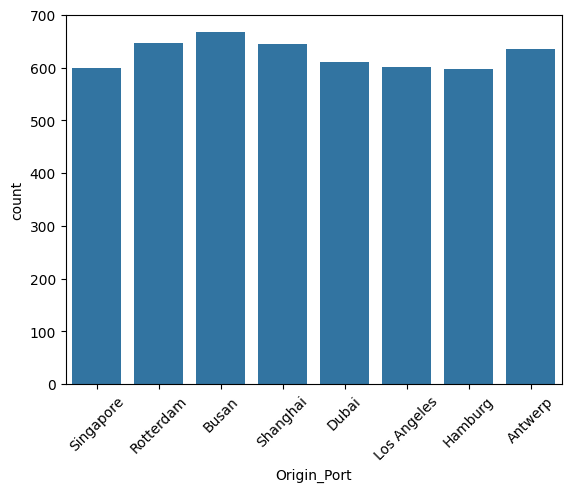

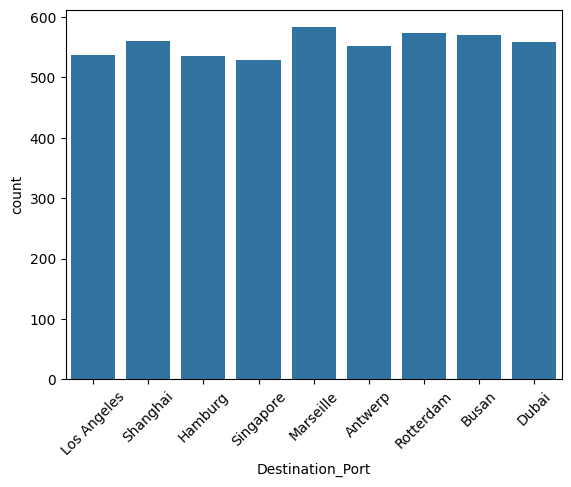

In [8]:
# Let's see the balance of where shipments are coming from and going to.
g = sns.countplot(supply, x='Origin_Port')
plt.xticks(rotation=45)
plt.show()
h = sns.countplot(supply, x='Destination_Port')
plt.xticks(rotation=45)
plt.show()
# Looks like the classes here are relatively balanced.
# These two columns are a major problem. They're important, but I can't condense any of them
# to be an "other" group. It could cause too many splits. I'll keep that in mind for later.

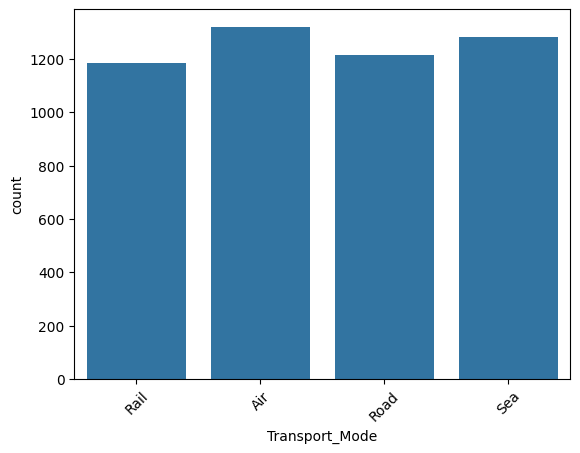

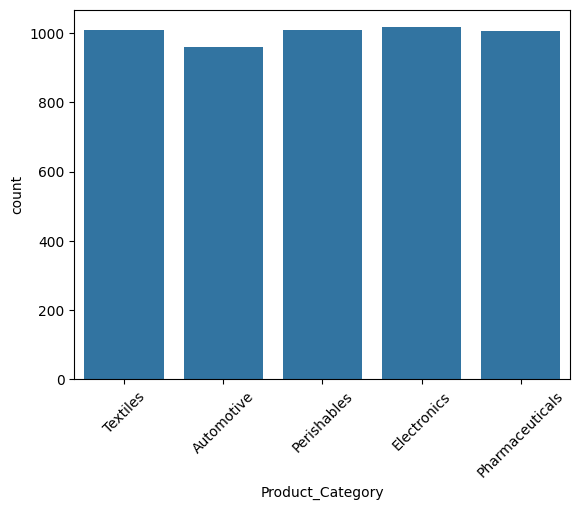

In [9]:
# How about the other two columns?
g = sns.countplot(supply, x='Transport_Mode')
plt.xticks(rotation=45)
plt.show()
h = sns.countplot(supply, x='Product_Category')
plt.xticks(rotation=45)
plt.show()

These two columns aren't condensible either! At least these two only have four and five groups, but that's still not ideal. Perhaps a different model would be better suited for using these...

In [10]:
# The date column isn't really useful as-is for a decision tree. I can see it being
# useful for non-binary decision trees, but since DecisionTreeClassifier is a binary
# tree it couldn't put small date ranges that correspond to geopolitical events such
# as wartimes in one node, it would take multiple splits to do so.
# I'll change it to something more easily classifiable: the seasonality of the shipment (weather during
# certain seasons is more intense than others, such as hurricanes in summer and anti-sea
# shipment conditions in winter)
# 
# Luckily, all of the ports are in the northern hemisphere (the Singapore one is technically
# north but on the equator so I'm going to count it as northern. I'll see if the shipments from
# Singapore have worse metrics because of this later.)

# Astronomical seasons are:
# Spring Mar 20 thru Jun 20
# Summer Jun 21 thru Sep 21
# Fall Sep 22 thru Dec 20
# Winter Dec 21 thru Mar 19
def season(date: str):
    dto = dt.strptime(date, '%Y-%m-%d')
    date = (dto.month, dto.day)
    # Tuple comparison lets you compare month first,  then 
    if date >= (3, 20) and date < (6, 21):
        return 'Spring'
    elif date >= (6, 21) and date < (9, 22):
        return 'Summer'
    elif date >= (9, 22) and date < (12, 20):
        return 'Fall'
    else:
        return 'Winter'
    
supply['Season'] = supply['Date'].apply(season)

In [11]:
# Drop the date column, it's not usable with DT
supply_season = supply.drop(columns='Date')

In [12]:
# Create X and Y DataFrames
X = supply_season.drop(columns='Disruption_Occurred')
y = supply_season[['Disruption_Occurred']]

In [13]:
# Positive class prevalence is...
print(sum(y['Disruption_Occurred']) / len(y))
# ...61%. Somewhat balanced, at least. Might need to adjust the class weighting.
# Since the goal is to minimize disruptions, detecting positive classes is more important.
# Maybe weighting won't be necessary. I'll try both.

0.6126


In [14]:
cat_cols = list(X.select_dtypes(include='object').columns)
# Here in case I need it - not necessary with decision tree models
#num_cols = list(supply.select_dtypes(include='number').columns)

preprocessor = ColumnTransformer(transformers=[
    ('ordinal', OrdinalEncoder(), cat_cols),
], remainder='passthrough')

/tmp/ipykernel_13509/828608070.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = list(X.select_dtypes(include='object').columns)


In [15]:
# Split 70-15-15 train-tune-test
Xtr, Xsp, ytr, ysp = train_test_split(X, y, train_size=0.7, random_state=random_seed)
Xtu, Xte, ytu, yte = train_test_split(Xsp, ysp, train_size=0.5, random_state=random_seed)

## The Approach

My approach is going to be an iterative one. Establishing a baseline with a known flawed model is a good way to show how much improvement each model gives. I'll start with a decision tree without parameters (heavy overfitting) to create a benchmark.

In [16]:
# Model 1: Completely unchecked decision tree (Intended to be bad and a baseline)
dt_pipe_1 = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('classifier', DecisionTreeClassifier(random_state=random_seed))
])

In [17]:
def model_fit_metrics(pipe: Pipeline, x, y, xt, yt, display_labels=['Safe', 'Disrupted']):
    """Fits a binary classification pipeline, then prints its training and tuning accuracy, 
    its classification report, and a confusion matrix display given training and testing X and Y.
    
    Args:
        pipe (sklearn.pipeline.Pipeline): A pipeline that has the fit() function.
        x (pd.DataFrame): The training features.
        y (pd.DataFrame): The training labels.
        xt (pd.DataFrame): The tuning features.
        yt (pd.DataFrame): The tuning labels.
        display_labels (list): The negative and positive class labels.
    Returns:
        pipe (sklearn.pipeline.Pipeline): The fitted pipeline.
        results (pd.DataFrame): A DataFrame with the columns: target, pred, prob_safe, prob_disrupted
    """
    pipe.fit(x, y)
    print("Training score:", pipe.score(x, y))
    print("Tuning score:", pipe.score(xt, yt))
    # Get better metrics than accuracy for tuning
    dt_pred = pipe.predict(xt)
    dt_prob = pipe.predict_proba(xt)

    # Bundle everything into a tidy DataFrame
    results = pd.DataFrame({
        'target': yt.squeeze(),
        'pred': dt_pred,
        'prob_safe': dt_prob[:, 0], # first column
        'prob_disrupted': dt_prob[:, 1] # second column
    })

    from sklearn.metrics import (
        confusion_matrix, ConfusionMatrixDisplay
    )
    cm = confusion_matrix(results['target'], results['pred'])
    display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    display.plot(cmap='Greens')
    print(classification_report(results['target'], results['pred'], target_names=display_labels))
    return pipe, results

Training score: 1.0
Tuning score: 0.6373333333333333
              precision    recall  f1-score   support

        Safe       0.52      0.54      0.53       286
   Disrupted       0.71      0.70      0.70       464

    accuracy                           0.64       750
   macro avg       0.62      0.62      0.62       750
weighted avg       0.64      0.64      0.64       750



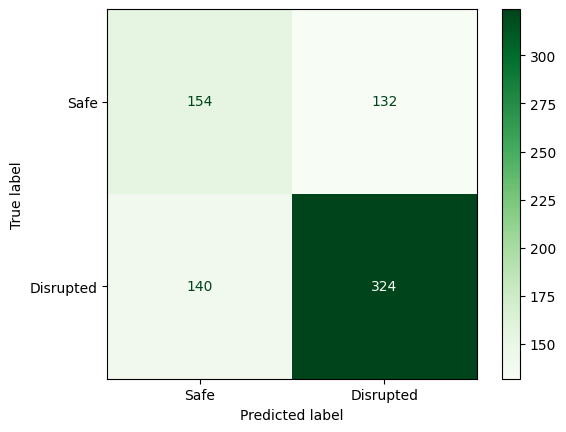

In [18]:
# Do a test with a single unchecked tree.
dt_pipe_1, results_1 = model_fit_metrics(dt_pipe_1, Xtr, ytr, Xtu, ytu)

In [19]:
# Package this code from our lab into a function - I'm going to use it a lot
def labeled_roc_auc_graph(results: pd.DataFrame, graphname, yhat_prob_colname='prob_disrupted', 
                          y_colname='target'):
    y_proba = results[yhat_prob_colname]
    ytarget = results[y_colname]
    fpr, tpr, thresholds = roc_curve(ytarget, y_proba)
    auc = roc_auc_score(ytarget, y_proba)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'{graphname} (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{graphname} ROC Curve')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f"{graphname} ROC-AUC: {auc:.4f}")
    return auc

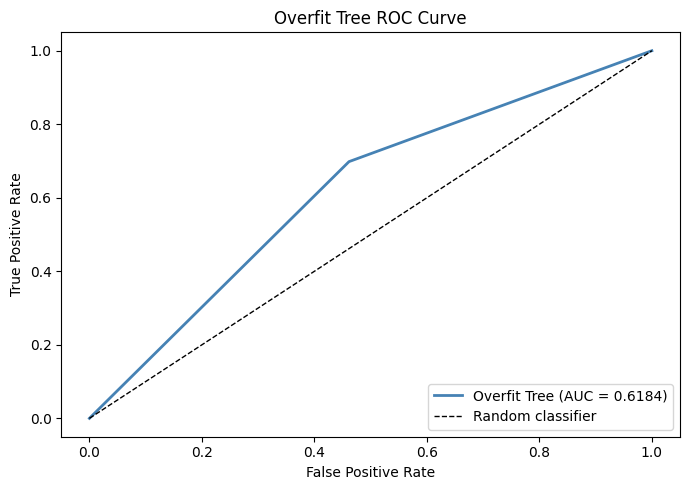

Overfit Tree ROC-AUC: 0.6184


In [20]:
# Let's see the ROC curve to check this model's robustness...
dt_1_roc_auc = labeled_roc_auc_graph(results_1, "Overfit Tree")

Rather weak showing on the ROC curve. This model isn't very robust. It makes sense, considering how it's meant to be fit to the training data and non-generalizable.

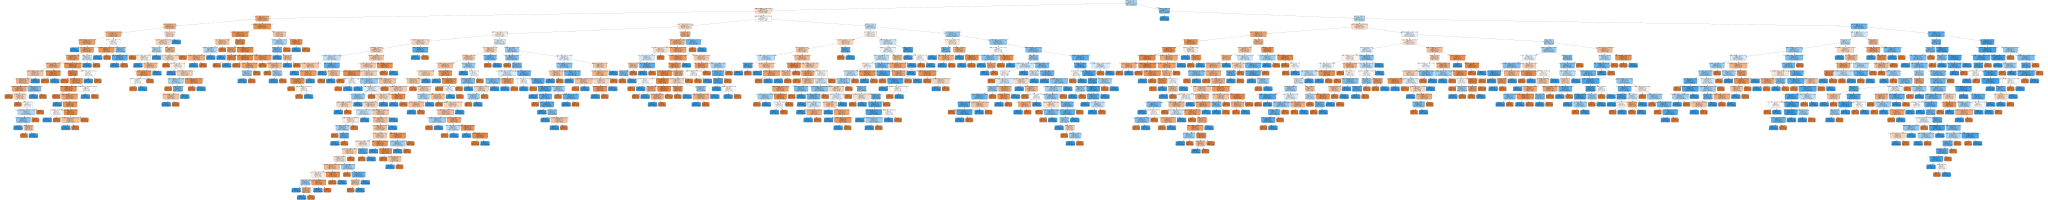

In [21]:
# Visualize the tree with a picture.
dot_data = export_graphviz(dt_pipe_1.named_steps['classifier'], out_file=None,
               feature_names=X.columns,
               filled=True,
               rounded=True,
               class_names=['safe','disrupted'])

graph = graphviz.Source(dot_data)
graph
# This graph is way too big. Let's make it more manageable.

Amazing training results, but 63.7% accurate on tuning data. That's not much better than just guessing it was disrupted every time. Negative precision and recall in particular are struggling, with less than 55% for both. However, since we're trying to detect potential delays, the positive recall is quite important, and it does at least hover around 70%. We can do better, though. 

This particular tree is a fantastic case of overfitting. Let's find some parameters that improve performance.  

In [22]:
# Let's try a grid search on parameters that might be useful.
# DT hyperparameters:
# criterion: 'entropy', 'gini', 'log-loss'
# splitter: 'best', 'random'
# max_depth: int
# min_samples_split: float
# min_samples_leaf: float
# max_features: 'auto', 'sqrt', 'log2', None, int (specific number), float 0<x<1 (fraction of features)
# max_leaf_nodes: int
# min_impurity_decrease: float
# class_weight: None, 'balanced', dictionary (manual adjustment of each column)

# Chosen parameters:
# Max depth: This tree has way, way too many layers. It's barely readable. Most splits beyond a 
#   small correction of just a few samples occur between 8-10 levels down. We'll try 6, 8, and 10.
# Minimum leaf samples: This tree has tons of splits at lower layers that split on... 5 values or less.
#   It's inefficient, and could use some clipping to make it easier to fit test data. 
#   I chose 20, 30, 40, and 50 because those numbers come up often in leaf nodes.
# Minimum impurity decrease: It looks like a good amount of the nodes don't decrease the impurity all
#   that much. Perhaps adding that as a restriction would be useful. I left 0 in because I'm unsure if
#   it will help at all, but I'm trying at the low end to make sure splits can still be made.
params = {
    "classifier__max_depth": (6, 8, 10),
    "classifier__min_samples_leaf": (20, 30, 40, 50),
    "classifier__min_impurity_decrease": (0, .1, .2, .3)
}

scoring = ['roc_auc','recall','balanced_accuracy']

gs_obj = GridSearchCV(estimator=dt_pipe_1,
                            param_grid=params, scoring=scoring, n_jobs=-1, 
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed),
                            refit='roc_auc')

gs_model = gs_obj.fit(Xtr, ytr)

In [23]:
best = gs_obj.best_estimator_
print(best)

# To access the underlying DecisionTreeClassifier from the pipeline:
best_clf = best.named_steps['classifier']
print('\nBest max_depth:', best_clf.max_depth)
print('\nBest min samples leaf:', best_clf.min_samples_leaf)
print('\nBest impurity decrease:', best_clf.min_impurity_decrease)
best_depth = best_clf.max_depth
best_leaf_samples = best_clf.min_samples_leaf
best_impurity_dec = best_clf.min_impurity_decrease

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['Origin_Port',
                                                   'Destination_Port',
                                                   'Transport_Mode',
                                                   'Product_Category',
                                                   'Weather_Condition',
                                                   'Season'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=8, min_impurity_decrease=0,
                                        min_samples_leaf=50,
                                        random_state=809))])

Best max_depth: 8

Best min samples leaf: 50

Best impurity decrease: 0


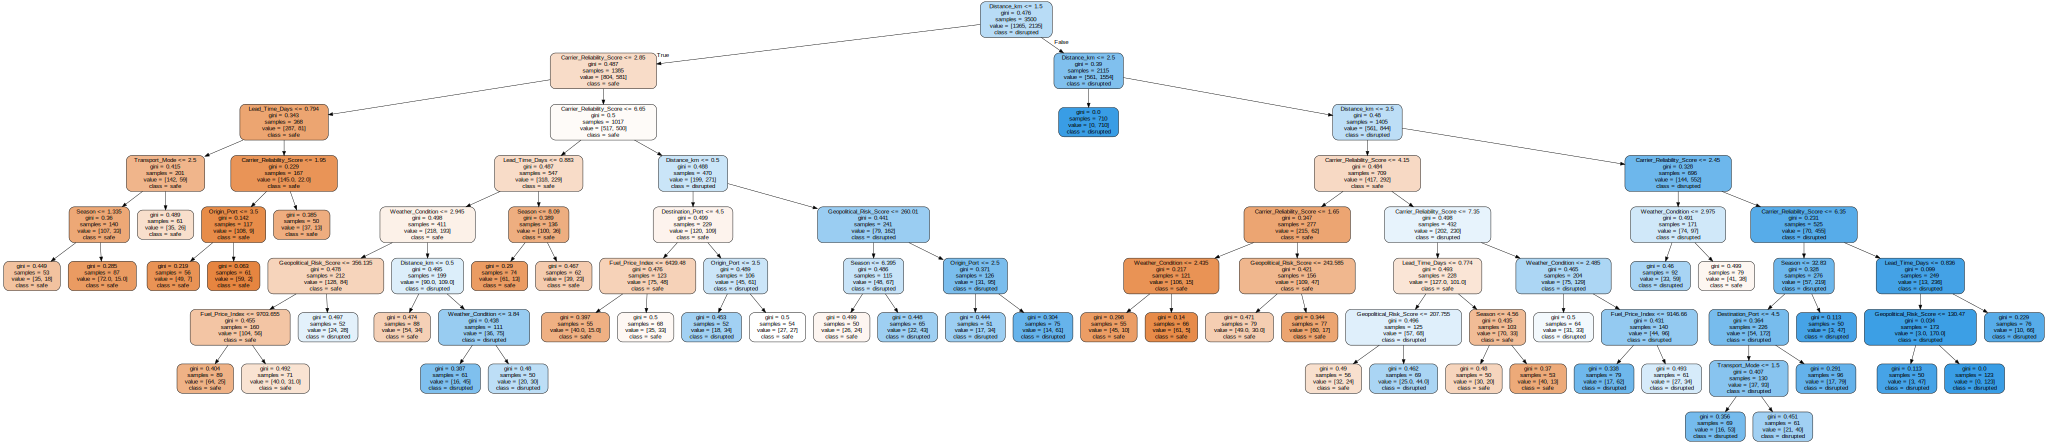

In [24]:
# Let's take this highest-performing model and visualize its tree.
dot_data = export_graphviz(best_clf, out_file=None,
               feature_names=X.columns,
               filled=True,
               rounded=True,
               class_names=['safe','disrupted'])

graph = graphviz.Source(dot_data)
graph

It looks like the biggest restrictor is the minimum samples requirement. Very few of the splits can actually get to the 8th level. In addition, the minimum impurity decrease parameter didn't help at all.

Now let's get the metrics on this highest-performing model and see how it compares to the unfit tree.

Training score: 0.7722857142857142
Tuning score: 0.6946666666666667
              precision    recall  f1-score   support

        Safe       0.58      0.69      0.63       286
   Disrupted       0.79      0.70      0.74       464

    accuracy                           0.69       750
   macro avg       0.68      0.69      0.69       750
weighted avg       0.71      0.69      0.70       750



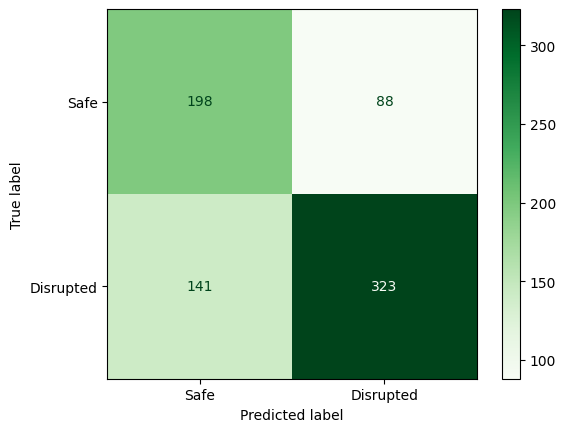

In [25]:
dt_pipe_2 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', best_clf)
))

dt_pipe_2, results_2 = model_fit_metrics(dt_pipe_2, Xtr, ytr, Xtu, ytu, 
                  display_labels=['Safe', 'Disrupted'])

And ROC-AUC...

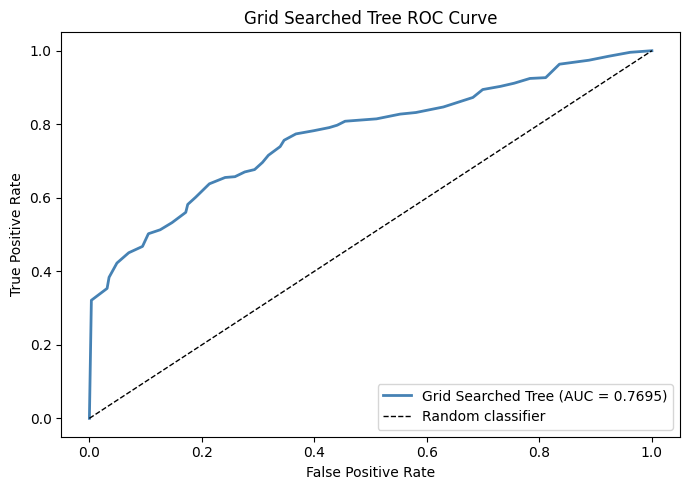

Grid Searched Tree ROC-AUC: 0.7695


In [26]:
dt_2_roc_auc = labeled_roc_auc_graph(results_2, "Grid Searched Tree")

Higher ROC-AUC compared to the first. This suggests that this model would be far more generalizable than the first.

## This model's metrics:
```
Training score: 0.7722857142857142
Tuning score: 0.6946666666666667
              precision    recall  f1-score   support

        Safe       0.58      0.69      0.63       286
   Disrupted       0.79      0.70      0.74       464

    accuracy                           0.69       750
   macro avg       0.68      0.69      0.69       750
weighted avg       0.71      0.69      0.70       750

```
## First model's metrics:
```
Training score: 1.0  
Tuning score: 0.6373333333333333  
              precision    recall  f1-score   support  
  
        Safe       0.52      0.54      0.53       286  
   Disrupted       0.71      0.70      0.70       464  
  
    accuracy                           0.64       750  
   macro avg       0.62      0.62      0.62       750  
weighted avg       0.64      0.64      0.64       750
```

Tuning accuracy has improved, but not too much. Performance on precision and recall improved across the board except for positive recall, which was the same. Unfortunate, considering that detecting disruptions is the point. Negative recall drastically improved, jumping from 54% to 69%. 

Balancing the classes should improve precision and recall for the negative class since it's the minority class, but disruption metrics should decrease. We'll explore it to see if it improves overall accuracy.

Training score: 0.7682857142857142
Tuning score: 0.692
              precision    recall  f1-score   support

        Safe       0.58      0.73      0.64       286
   Disrupted       0.80      0.67      0.73       464

    accuracy                           0.69       750
   macro avg       0.69      0.70      0.69       750
weighted avg       0.72      0.69      0.70       750



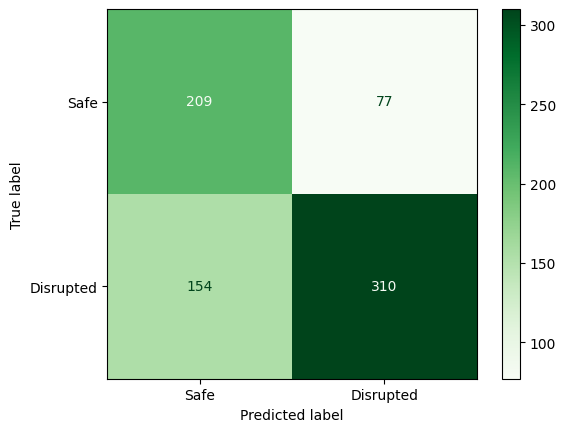

In [27]:
# Let's see if balancing the classes helps.
best_balanced = copy.deepcopy(best_clf)
best_balanced.class_weight = 'balanced'

dt_pipe_3 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', best_balanced)
))

dt_pipe_3, results_3 = model_fit_metrics(dt_pipe_3, Xtr, ytr, Xtu, ytu, 
                  display_labels=['Safe', 'Disrupted'])

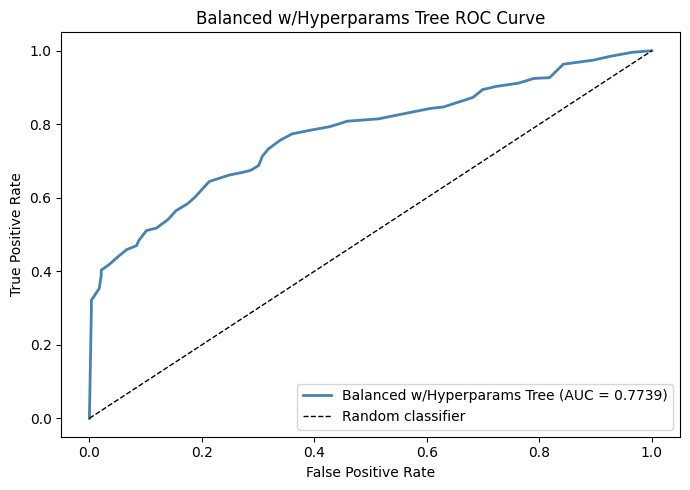

Balanced w/Hyperparams Tree ROC-AUC: 0.7739


0.7738839823969133

In [28]:
labeled_roc_auc_graph(results_3, "Balanced w/Hyperparams Tree")

Interestingly, the ROC curve suggests slightly better generalizability for this model, despite overall accuracy decreasing. However, positive recall does decrease quite a bit, which is a key part of what we're searching for in making these models. We'd have to be cautious between picking this model and the previous one.

Let's see the feature importances for each of these previous models and see if that grants any insight about the dataset.

In [29]:
imp_1 = pd.DataFrame(dt_pipe_1.named_steps['classifier'].feature_importances_,index=X.columns,columns=['importance']).sort_values('importance', ascending=False)
imp_2 = pd.DataFrame(dt_pipe_2.named_steps['classifier'].feature_importances_,index=X.columns,columns=['importance']).sort_values('importance', ascending=False)
imp_3 = pd.DataFrame(dt_pipe_3.named_steps['classifier'].feature_importances_,index=X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(imp_1)
print(imp_2)
print(imp_3)


                           importance
Distance_km                  0.261885
Carrier_Reliability_Score    0.156640
Weather_Condition            0.095820
Lead_Time_Days               0.095049
Geopolitical_Risk_Score      0.091556
Fuel_Price_Index             0.084739
Season                       0.068637
Destination_Port             0.039366
Origin_Port                  0.038894
Product_Category             0.025534
Weight_MT                    0.023474
Transport_Mode               0.018405
                           importance
Distance_km                  0.683871
Carrier_Reliability_Score    0.201217
Lead_Time_Days               0.031957
Geopolitical_Risk_Score      0.017639
Weather_Condition            0.017492
Season                       0.015887
Fuel_Price_Index             0.012896
Destination_Port             0.008129
Transport_Mode               0.006119
Origin_Port                  0.004793
Product_Category             0.000000
Weight_MT                    0.000000
            

It looks like distance has a disproportionately large contribution regardless of the model parameters. This does give a valuable point about answering our question, though - *one possible explanation for a shipment going wrong is how far away the shipment has to go.* It's kind of common sense - the longer the trip is, the more time there is for something to fail.

The top features between models tend to be:
- Distance
- Carrier reliability
- Lead time

Seasonality is important if you balance the classes, but not otherwise. Lead time also came up in the other modeling techniques as an important feature, but it's not as prevalent in this modeling technique.


## Cost-Complexity Pruning - A Different Parameter Search

Let's try minimum cost-complexity pruning (CCP) instead of grid searching  and see if that is more effective than a grid search.  
CCP is a technique where you progressively remove the terminal nodes of the tree (whichever has the least benefit for its split) and sacrifice some of the training accuracy to prevent overfitting and improve testing accuracy. Every permutation of the full, overfit tree (with splits removed) is scored according to $S = Loss + \alpha * T$, where $T$ is the number of leaf nodes. The tree with the lowest score is selected. In effect, a higher alpha creates trees that have fewer leaves.

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

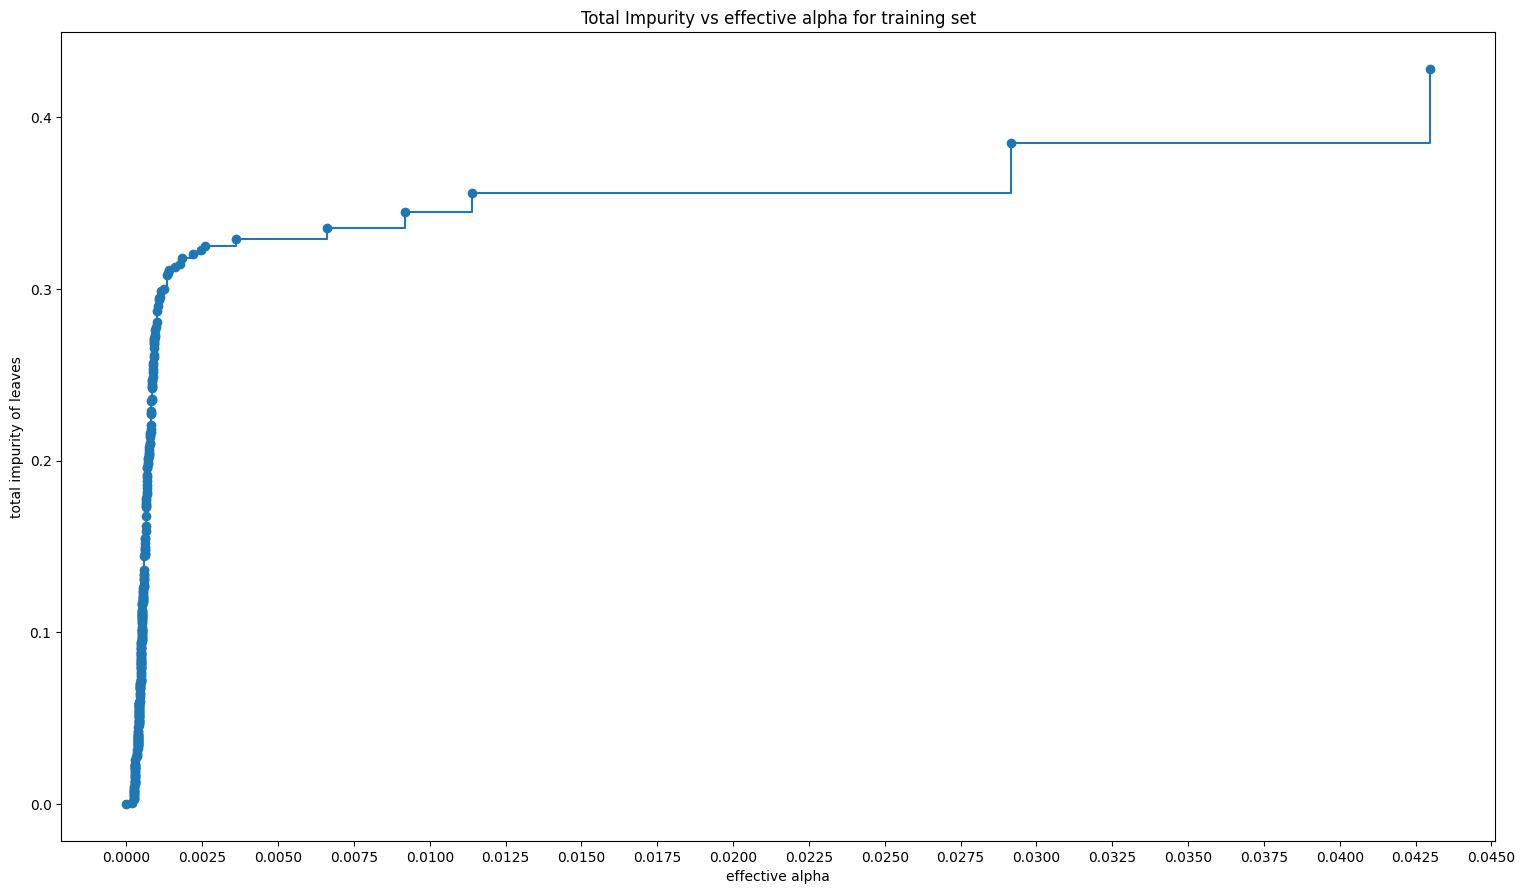

In [30]:
path_disrupt = dt_pipe_1.named_steps['classifier'].cost_complexity_pruning_path(
    dt_pipe_1.named_steps['preprocessor'].fit_transform(Xtr), ytr
)

# The path_disrupt line above returns two values: Alpha parameter thresholds where leaves 
# are cut (ccp_alphas) and the sum of weighted impurities in the tree's leaves 
# at those alpha levels (impurities)
ccp_alphas, impurities = path_disrupt.ccp_alphas, path_disrupt.impurities

fig, ax = plt.subplots()
# In the following plot, the maximum effective alpha value is removed, because it is the 
# trivial tree with only one node
fig.set_size_inches(18.5, 10.5, forward=True)
plt.xticks(ticks=np.arange(0.00,0.06,.0025))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax.set_title("Total Impurity vs effective alpha for training set")

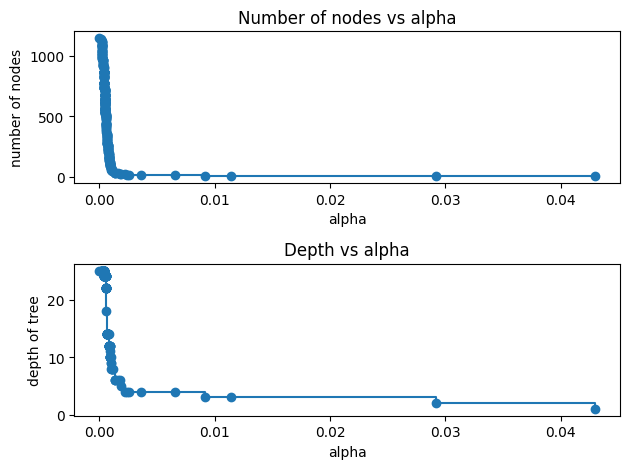

In [31]:
# This function creates a bunch of pipelines, one at each alpha threshold value where leaves are cut off.
# This lets you see results as you cut down more and more of the tree.
clfs = []
for ccp_alpha in ccp_alphas:
    clf_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=random_seed, ccp_alpha=ccp_alpha))
    ])
    clf_pipe.fit(Xtr, ytr)
    clfs.append(clf_pipe)
    
#The last model is a single-node tree, which is trivial, so we remove it.
clfs = clfs[:-1]
ccp_alphas = ccp_alphas[:-1]

# Two graphs are displayed here.
# The top graph shows that there are fewer nodes as alpha goes up and prunes more of them.
# The bottom graph shows that the tree also gets shallower as more leaves are pruned.
node_counts = [clf.named_steps['classifier'].tree_.node_count for clf in clfs]
depth = [clf.named_steps['classifier'].tree_.max_depth  for clf in clfs]
fig, ax = plt.subplots(2, 1)
ax[0].plot(ccp_alphas, node_counts, marker='o', drawstyle='steps-post')
ax[0].set_xlabel('alpha')
ax[0].set_ylabel('number of nodes')
ax[0].set_title('Number of nodes vs alpha')

ax[1].plot(ccp_alphas, depth, marker='o', drawstyle='steps-post')
ax[1].set_xlabel('alpha')
ax[1].set_ylabel('depth of tree')
ax[1].set_title('Depth vs alpha')
fig.tight_layout()
plt.show()

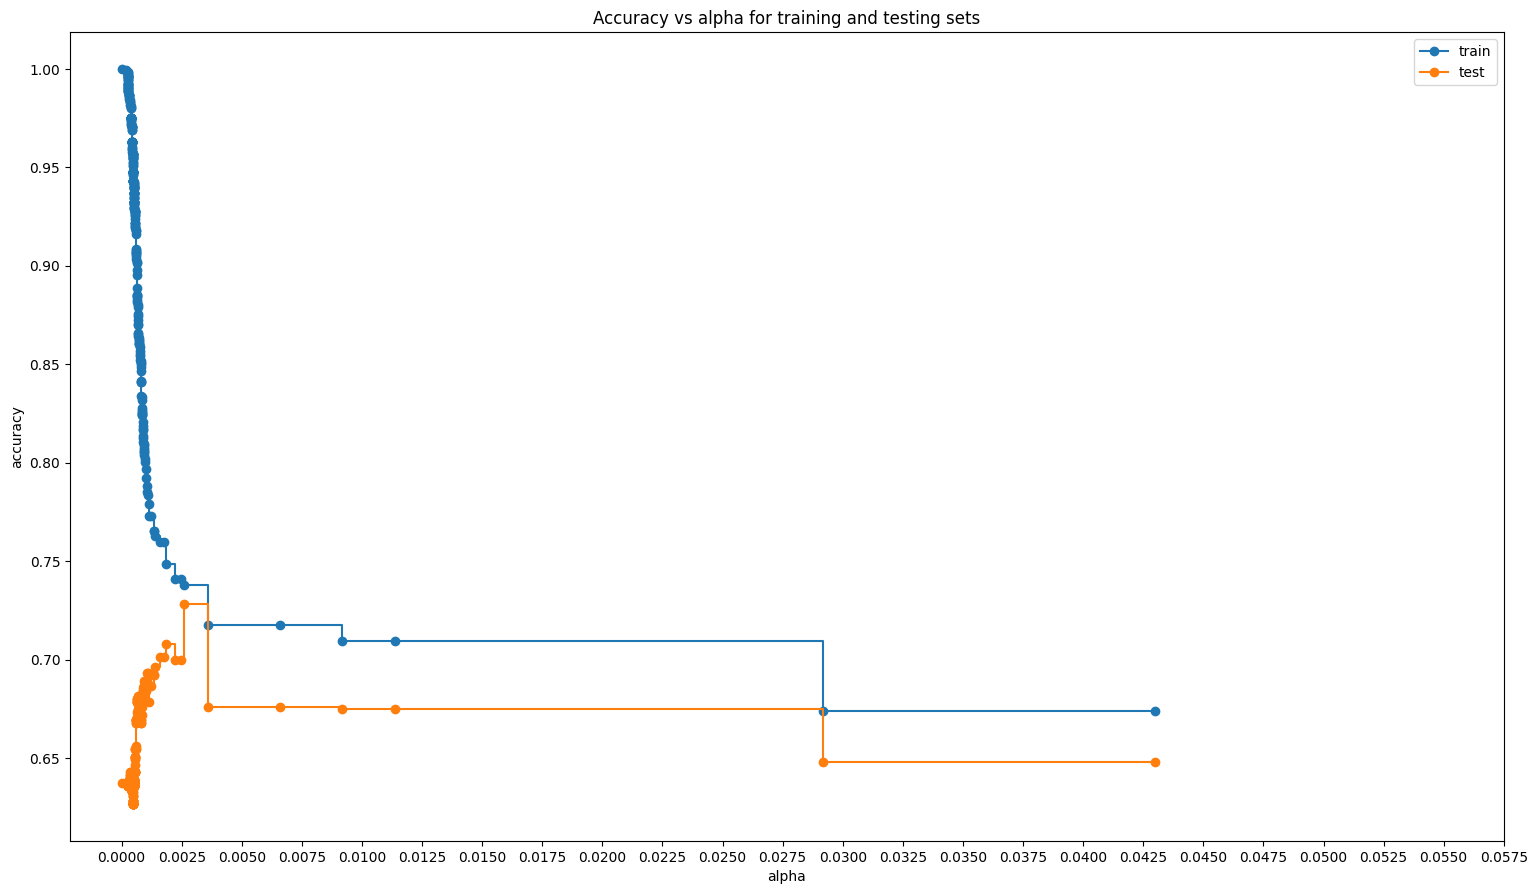

In [32]:
# Get train and test accuracy for each tree pruning level
train_scores = [clf.score(Xtr, ytr) for clf in clfs]
test_scores = [clf.score(Xtu, ytu) for clf in clfs]

# This graph shows the test and train scores. Note how train score decreases monotonically while
# testing accuracy goes up and then back down again. We want to choose the alpha where test accuracy 
# is maximized.
fig, ax = plt.subplots()
ax.set_xlabel("alpha")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs alpha for training and testing sets")
ax.plot(ccp_alphas, train_scores, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.xticks(ticks=np.arange(0.00,0.06,.0025))
fig.set_size_inches(18.5, 10.5, forward=True)
plt.show()

In [33]:
# Let's get the index of the model with the alpha that gives the highest testing accuracy with argmax
best_index = np.argmax(test_scores)
# Print out the accuracy for that model
print(test_scores[best_index])
# Extract that pipeline from the list
best_alpha_pipe = clfs[best_index]
# Finally, get the alpha value
print(best_alpha_pipe.named_steps['classifier'].ccp_alpha)

0.728
0.00258337989801391


Training score: 0.738
Tuning score: 0.728
              precision    recall  f1-score   support

        Safe       0.66      0.60      0.63       286
   Disrupted       0.77      0.80      0.79       464

    accuracy                           0.73       750
   macro avg       0.71      0.70      0.71       750
weighted avg       0.72      0.73      0.73       750



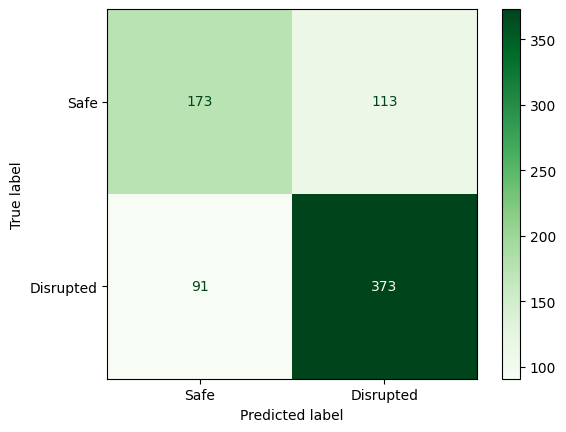

In [34]:
# Finally, get the metrics for this model with optimal pruning
dt_pipe_4, results_4 = model_fit_metrics(best_alpha_pipe, Xtr, ytr, Xtu, ytu, display_labels=['Safe', 'Disrupted'])

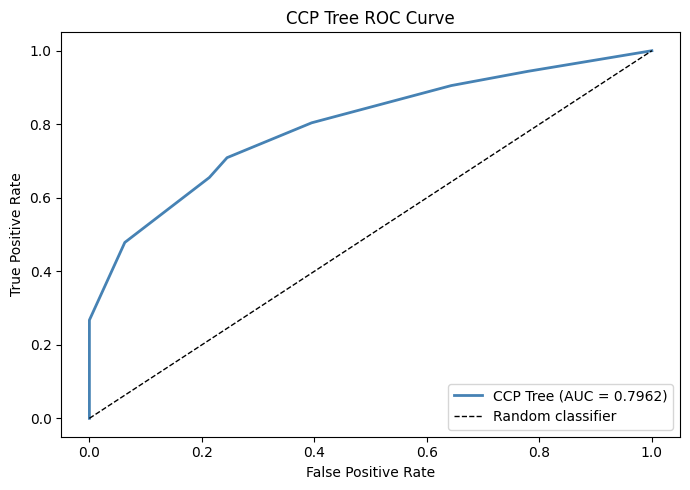

CCP Tree ROC-AUC: 0.7962


0.7962081022425851

In [35]:
labeled_roc_auc_graph(results_4, 'CCP Tree')

### Grid search model's metrics:
```
Training score: 0.7722857142857142
Tuning score: 0.6946666666666667
              precision    recall  f1-score   support

        Safe       0.58      0.69      0.63       286
   Disrupted       0.79      0.70      0.74       464

    accuracy                           0.69       750
   macro avg       0.68      0.69      0.69       750
weighted avg       0.71      0.69      0.70       750

```
### This model's metrics:
```
Training score: 0.738
Tuning score: 0.728
              precision    recall  f1-score   support

        Safe       0.66      0.60      0.63       286
   Disrupted       0.77      0.80      0.79       464

    accuracy                           0.73       750
   macro avg       0.71      0.70      0.71       750
weighted avg       0.72      0.73      0.73       750
```
On the tuning data, accuracy improves by a few percentage points, and positive recall goes up by a lot with only a small decrease in precision. In addition, it has the best ROC-AUC so far. Great. It's still only about 11% more accurate than just guessing "It got disrupted" every single time. Negative recall is a big failure point on this model. This is, however, the best model at detecting the true positives, and is right a bit more 3/4 of the time in its delay predictions.

## Random Forest - An Ensemble of Decision Trees

Finally, let's give a random forest a try. No parameters at first, just to see if base performace is better. Then we'll find some good ones.

/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training score: 1.0
Tuning score: 0.6946666666666667
              precision    recall  f1-score   support

        Safe       0.60      0.61      0.60       286
   Disrupted       0.76      0.75      0.75       464

    accuracy                           0.69       750
   macro avg       0.68      0.68      0.68       750
weighted avg       0.70      0.69      0.70       750



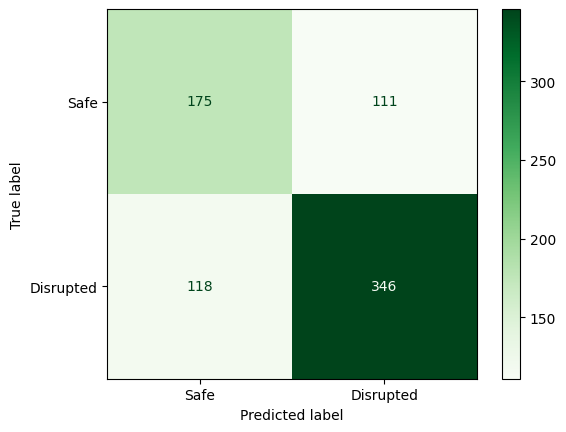

In [36]:
rf_pipe_1 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=random_seed))
))

rf_pipe_1, results_rf_1 = model_fit_metrics(rf_pipe_1, Xtr, ytr, Xtu, ytu, display_labels=['Safe', 'Disrupted'])

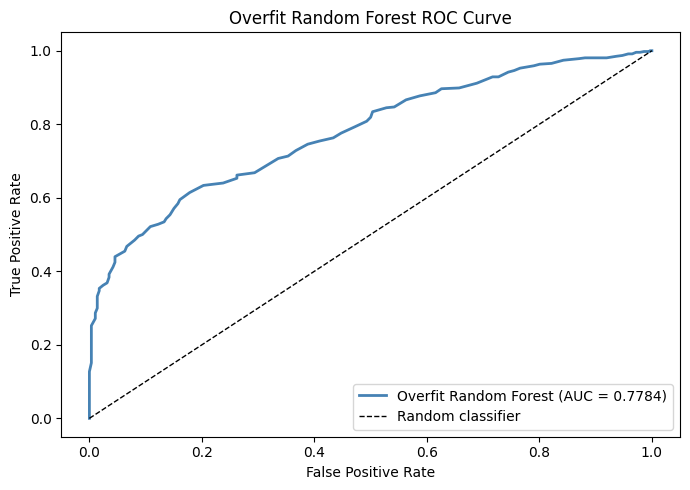

Overfit Random Forest ROC-AUC: 0.7784


0.7784354653966724

In [37]:
labeled_roc_auc_graph(results_rf_1, 'Overfit Random Forest')

### Overfit tree metrics:
```
Training score: 1.0
Tuning score: 0.6373333333333333
              precision    recall  f1-score   support

        Safe       0.52      0.54      0.53       286
   Disrupted       0.71      0.70      0.70       464

    accuracy                           0.64       750
   macro avg       0.62      0.62      0.62       750
weighted avg       0.64      0.64      0.64       750
```
### Overfit forest metrics:
```
Training score: 1.0
Tuning score: 0.6946666666666667
              precision    recall  f1-score   support

        Safe       0.60      0.61      0.60       286
   Disrupted       0.76      0.75      0.75       464

    accuracy                           0.69       750
   macro avg       0.68      0.68      0.68       750
weighted avg       0.70      0.69      0.70       750
```
It's already on par with the grid-searched tree, without any parameters! Let's see if we can improve the model with the previously grid-searched parameters...

In [43]:
import warnings
warnings.filterwarnings("ignore") 
# Warning is about the y dimension being 1 instead of empty, code functions identically

scoring_rf = ['roc_auc','recall','balanced_accuracy']

params_rf = {
    "classifier__max_depth": (6, 8, 10),
    "classifier__min_samples_leaf": (20, 30, 40, 50),
    "classifier__min_impurity_decrease": (0, .1, .2, .3)
}

gs_obj_rf = GridSearchCV(estimator=rf_pipe_1,
                            param_grid=params_rf, scoring=scoring_rf, n_jobs=-1, 
                            cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed),
                            refit='roc_auc')

gs_model_rf = gs_obj_rf.fit(Xtr, ytr)

In [39]:
best_rf = gs_obj_rf.best_estimator_
print(best_rf)

# To access the underlying DecisionTreeClassifier from the pipeline:
best_clf_rf = best_rf.named_steps['classifier']
print('\nBest max_depth:', best_clf_rf.max_depth)
print('\nBest min samples leaf:', best_clf_rf.min_samples_leaf)
print('\nBest impurity decrease:', best_clf_rf.min_impurity_decrease)
best_depth_rf = best_clf_rf.max_depth
best_leaf_samples_rf = best_clf_rf.min_samples_leaf
best_impurity_dec_rf = best_clf_rf.min_impurity_decrease

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinal', OrdinalEncoder(),
                                                  ['Origin_Port',
                                                   'Destination_Port',
                                                   'Transport_Mode',
                                                   'Product_Category',
                                                   'Weather_Condition',
                                                   'Season'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, min_impurity_decrease=0,
                                        min_samples_leaf=30,
                                        random_state=809))])

Best max_depth: 8

Best min samples leaf: 30

Best impurity decrease: 0


/workspaces/DS3021-final/.venv/lib/python3.12/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training score: 0.7817142857142857
Tuning score: 0.7026666666666667
              precision    recall  f1-score   support

        Safe       0.62      0.58      0.60       286
   Disrupted       0.75      0.78      0.76       464

    accuracy                           0.70       750
   macro avg       0.68      0.68      0.68       750
weighted avg       0.70      0.70      0.70       750



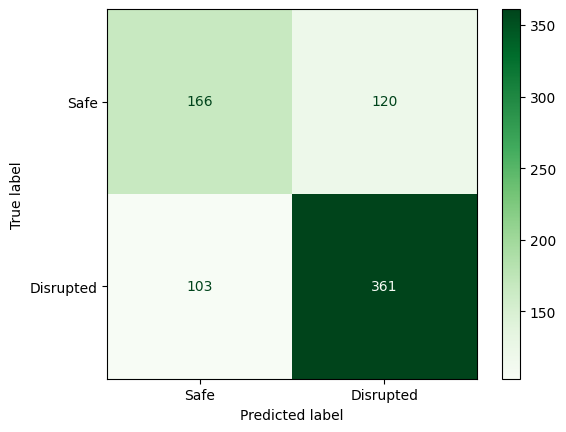

In [40]:
rf_pipe_2 = Pipeline(steps=(
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(max_depth=best_depth_rf,
                                          min_samples_leaf=best_leaf_samples_rf,
                                          min_impurity_decrease=best_impurity_dec_rf,
                                          random_state=random_seed))
))
rf_pipe_2, results_rf_2 = model_fit_metrics(rf_pipe_2, Xtr, ytr, Xtu, ytu, display_labels=['Safe','Disrupted'])

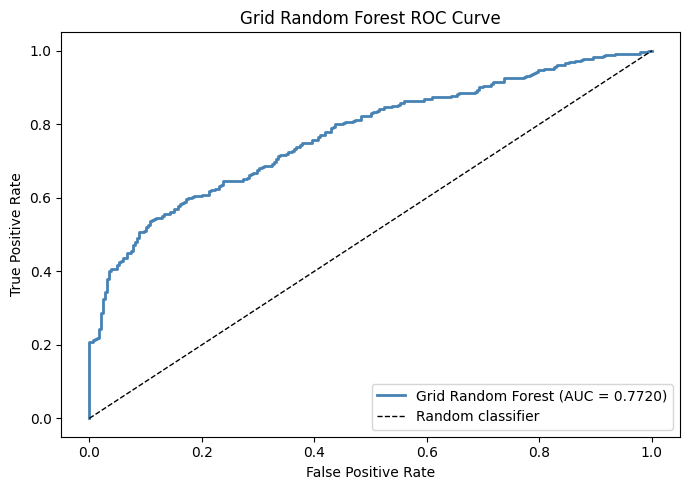

Grid Random Forest ROC-AUC: 0.7720


0.7720038582107548

In [41]:
labeled_roc_auc_graph(results_rf_2, 'Grid Random Forest')

### Best tree's metrics:
```
Training score: 0.738
Tuning score: 0.728
              precision    recall  f1-score   support

        Safe       0.66      0.60      0.63       286
   Disrupted       0.77      0.80      0.79       464

    accuracy                           0.73       750
   macro avg       0.71      0.70      0.71       750
weighted avg       0.72      0.73      0.73       750
```
### Parametered forest metrics
```
Training score: 0.7817142857142857
Tuning score: 0.7026666666666667
              precision    recall  f1-score   support

        Safe       0.62      0.58      0.60       286
   Disrupted       0.75      0.78      0.76       464

    accuracy                           0.70       750
   macro avg       0.68      0.68      0.68       750
weighted avg       0.70      0.70      0.70       750
```
It's actually less effective than pruning the single tree on the tuning set! Goes to show that one well-thought-out model can perform really well, even when up against many less effective ones working together.

## The Final Challenge - The Test Data
Let's see how each of our previous models performs on data that it hasn't been tuned for.

In [42]:
print("Overfit tree test score: ", dt_pipe_1.score(Xte, yte))
print("Grid search tree test score: ", dt_pipe_2.score(Xte, yte))
print("Balanced grid tree test score: ", dt_pipe_3.score(Xte, yte))
print("Min cost-complexity pruned tree test score: ", best_alpha_pipe.score(Xte, yte))
print("Overfit forest test score: ", rf_pipe_1.score(Xte, yte))
print("Grid search forest test score: ", rf_pipe_2.score(Xte, yte))

Overfit tree test score:  0.6853333333333333
Grid search tree test score:  0.6933333333333334
Balanced grid tree test score:  0.6933333333333334
Min cost-complexity pruned tree test score:  0.7213333333333334
Overfit forest test score:  0.7093333333333334
Grid search forest test score:  0.712


Interesting set of results... 
- The overfit tree seems to score much better on this set of testing data. My guess is that it was just a lucky set that fit more closely to the training data, since it's heavily overfit.
- The parameterized tree and balanced parameterized tree perform just a bit worse, but are much more in line with how it performed before. This suggests consistent performance with new data.
- The CCP tree performs very well, in fact, it is the strongest model of the bunch. It also performs similarly to the tuning data, suggesting it applies well to unknown data.
- Both random forests perform relatively similarly to their tuning results (within 1%), so these models might be more generalizable to other data.

## Final Notes
In terms of prediction, these models seem to be capable of getting results better than simply guessing the majority class, but not by much. This is likely at least partially caused by many of the categorical classes being many balanced factors that I wasn't able to condense. I was never able to get any precision or recall metrics anywhere above 80%. I was hoping for 85% or more, considering how important being able to plan for incoming shipments is. If I were to choose one model to move forward with, I would probably choose one of the random forests, since it is likely more robust due to the selection involving feature subsets despite its slightly lower metrics.

In comparison with the other models, these ones appear similar in performance to kNN and slightly inferior to logistic regression. However, none of the chosen models are able to predict the outcome of whether a shipment will be delayed without a significant degree of uncertainty. It seems like, at least for these models, delays of shipments are much more volatile than what can be predicted reliably with our chosen modeling techniques given this data. Logistic regression tends to have better overall metrics than these decision tree models, which makes sense given that it can handle the categorical variables with balanced classes more effectively.